
========== EXPENSE DATA ==========
         Date        Description  Amount Payment_Mode
0  2026-08-01       Monthly Rent   12000          UPI
1  2026-08-02   Grocery Shopping    3500         Card
2  2026-08-03   Electricity Bill    1800          UPI
3  2026-08-04          Uber Ride     450          UPI
4  2026-08-05  Restaurant Dinner    1200         Card

========== DATA CLEANING ==========

Missing Values:
Date            0
Description     0
Amount          0
Payment_Mode    0
dtype: int64

Duplicate Rows:
0

========== CATEGORIZED EXPENSES ==========
          Description  Amount       Category
0        Monthly Rent   12000        Housing
1    Grocery Shopping    3500           Food
2    Electricity Bill    1800          Bills
3           Uber Ride     450      Transport
4   Restaurant Dinner    1200           Food
5     Online Shopping    2200       Shopping
6       Movie Tickets     600  Entertainment
7     Mobile Recharge     500          Bills
8    Grocery Shopping    2800    

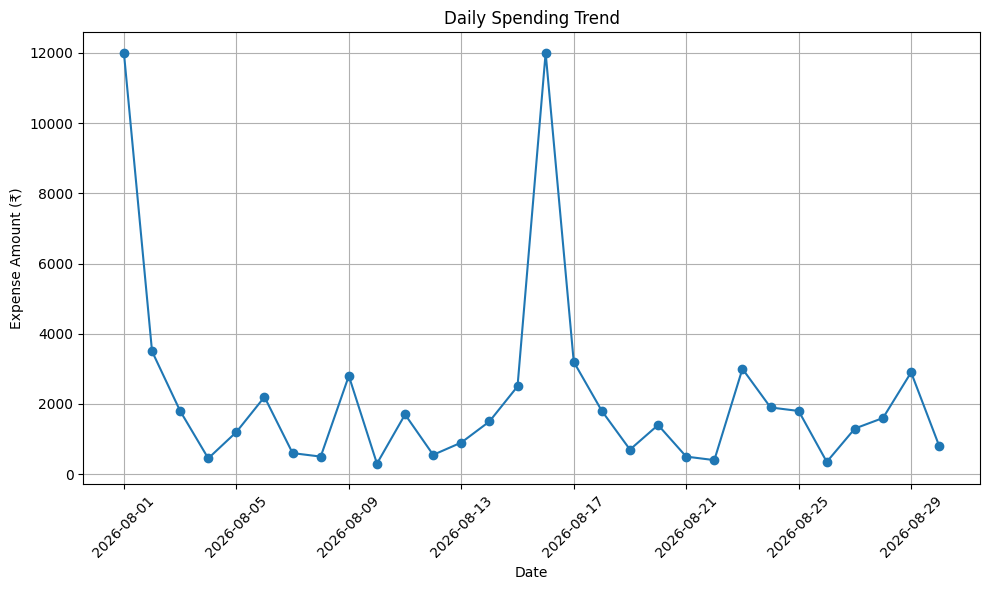

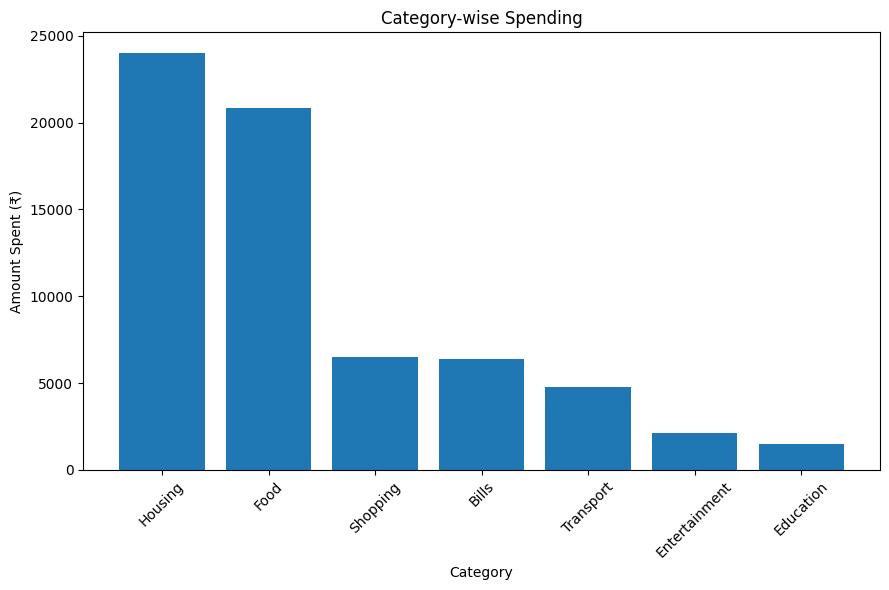


========== EXPENSE PREDICTION ==========
Average Daily Expense: ₹ 2205.0
Predicted Monthly Expense: ₹ 66150.0
Predicted Monthly Savings: ₹ -16150.0

✅ Expense report exported!
Files:
1. expense_report.csv
2. budget_summary.csv

========== FINAL SUMMARY ==========
Total Expense: ₹ 66150
Monthly Income: ₹ 50000
Monthly Savings: ₹ -16150
Savings Percentage: -32.3 %
Highest Spending Category: Housing
Highest Category Expense: ₹ 24000
Predicted Monthly Expense: ₹ 66150.0

🎉 SMART EXPENSE ANALYZER COMPLETED!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


# ==========================================
# 1. READ CSV FILE
# ==========================================

df = pd.read_csv("expense_data.csv")

print("\n========== EXPENSE DATA ==========")
print(df.head())


# ==========================================
# 2. DATA CLEANING
# ==========================================

print("\n========== DATA CLEANING ==========")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Remove duplicate records
df = df.drop_duplicates()

# Remove rows with missing values
df = df.dropna()

# Convert Date
df["Date"] = pd.to_datetime(df["Date"])

# Convert Amount to numeric
df["Amount"] = pd.to_numeric(df["Amount"])


# ==========================================
# 3. AUTOMATIC EXPENSE CATEGORIZATION
# ==========================================

def categorize_expense(description):

    description = description.lower()

    if any(word in description for word in [
        "rent"
    ]):
        return "Housing"

    elif any(word in description for word in [
        "grocery",
        "food",
        "restaurant",
        "coffee"
    ]):
        return "Food"

    elif any(word in description for word in [
        "uber",
        "petrol",
        "transport"
    ]):
        return "Transport"

    elif any(word in description for word in [
        "electricity",
        "mobile",
        "recharge"
    ]):
        return "Bills"

    elif any(word in description for word in [
        "movie",
        "entertainment"
    ]):
        return "Entertainment"

    elif any(word in description for word in [
        "shopping",
        "clothes"
    ]):
        return "Shopping"

    elif any(word in description for word in [
        "course",
        "education"
    ]):
        return "Education"

    else:
        return "Other"


df["Category"] = df["Description"].apply(
    categorize_expense
)


print("\n========== CATEGORIZED EXPENSES ==========")

print(
    df[
        [
            "Description",
            "Amount",
            "Category"
        ]
    ].head(15)
)


# ==========================================
# 4. TOTAL EXPENSE
# ==========================================

total_expense = df["Amount"].sum()

print("\n========== EXPENSE SUMMARY ==========")

print(
    "Total Expense: ₹",
    round(total_expense, 2)
)


# ==========================================
# 5. MONTHLY INCOME
# ==========================================

# Assumed monthly income for this project

monthly_income = 50000


# ==========================================
# 6. MONTHLY SAVINGS
# ==========================================

monthly_savings = (
    monthly_income
    - total_expense
)


savings_percentage = (
    monthly_savings
    / monthly_income
) * 100


print(
    "Monthly Income: ₹",
    monthly_income
)

print(
    "Monthly Savings: ₹",
    round(monthly_savings, 2)
)

print(
    "Savings Percentage:",
    round(savings_percentage, 2),
    "%"
)


# ==========================================
# 7. CATEGORY-WISE EXPENSE
# ==========================================

category_expense = (
    df.groupby("Category")["Amount"]
    .sum()
    .sort_values(
        ascending=False
    )
)


print("\n========== CATEGORY-WISE EXPENSE ==========")

print(category_expense)


# ==========================================
# 8. BUDGET SUMMARY
# ==========================================

budget = {
    "Housing": 15000,
    "Food": 10000,
    "Transport": 5000,
    "Bills": 5000,
    "Entertainment": 3000,
    "Shopping": 5000,
    "Education": 3000,
    "Other": 2000
}


budget_summary = []


for category, limit in budget.items():

    spent = category_expense.get(
        category,
        0
    )

    remaining = limit - spent

    if spent > limit:
        status = "Over Budget"

    else:
        status = "Within Budget"


    budget_summary.append({

        "Category": category,

        "Budget": limit,

        "Spent": round(
            spent,
            2
        ),

        "Remaining": round(
            remaining,
            2
        ),

        "Status": status
    })


budget_df = pd.DataFrame(
    budget_summary
)


print("\n========== BUDGET SUMMARY ==========")

print(
    budget_df.to_string(
        index=False
    )
)


# ==========================================
# 9. SPENDING TREND
# ==========================================

daily_expense = (
    df.groupby("Date")["Amount"]
    .sum()
)


plt.figure(figsize=(10, 6))

plt.plot(
    daily_expense.index,
    daily_expense.values,
    marker="o"
)

plt.title(
    "Daily Spending Trend"
)

plt.xlabel("Date")

plt.ylabel(
    "Expense Amount (₹)"
)

plt.xticks(
    rotation=45
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "spending_trend.png"
)

plt.show()


# ==========================================
# 10. CATEGORY CHART
# ==========================================

plt.figure(figsize=(9, 6))

plt.bar(
    category_expense.index,
    category_expense.values
)

plt.title(
    "Category-wise Spending"
)

plt.xlabel("Category")

plt.ylabel(
    "Amount Spent (₹)"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    "category_spending.png"
)

plt.show()


# ==========================================
# 11. EXPENSE PREDICTION
# ==========================================

# Calculate average daily expense

average_daily_expense = (
    df["Amount"].mean()
)


# Predict next 7 days

predicted_monthly_expense = (
    average_daily_expense * 30
)


print("\n========== EXPENSE PREDICTION ==========")

print(
    "Average Daily Expense: ₹",
    round(
        average_daily_expense,
        2
    )
)

print(
    "Predicted Monthly Expense: ₹",
    round(
        predicted_monthly_expense,
        2
    )
)


# ==========================================
# 12. PREDICTED SAVINGS
# ==========================================

predicted_savings = (
    monthly_income
    - predicted_monthly_expense
)


print(
    "Predicted Monthly Savings: ₹",
    round(
        predicted_savings,
        2
    )
)


# ==========================================
# 13. EXPORT FINAL REPORT
# ==========================================

df.to_csv(
    "expense_report.csv",
    index=False
)


budget_df.to_csv(
    "budget_summary.csv",
    index=False
)


print(
    "\n✅ Expense report exported!"
)

print(
    "Files:"
)

print(
    "1. expense_report.csv"
)

print(
    "2. budget_summary.csv"
)


# ==========================================
# 14. FINAL SUMMARY
# ==========================================

print("\n========== FINAL SUMMARY ==========")

print(
    "Total Expense: ₹",
    round(
        total_expense,
        2
    )
)

print(
    "Monthly Income: ₹",
    monthly_income
)

print(
    "Monthly Savings: ₹",
    round(
        monthly_savings,
        2
    )
)

print(
    "Savings Percentage:",
    round(
        savings_percentage,
        2
    ),
    "%"
)

print(
    "Highest Spending Category:",
    category_expense.idxmax()
)

print(
    "Highest Category Expense: ₹",
    category_expense.max()
)

print(
    "Predicted Monthly Expense: ₹",
    round(
        predicted_monthly_expense,
        2
    )
)

print(
    "\n🎉 SMART EXPENSE ANALYZER COMPLETED!"
)